### (b) Bias DeepLDA

## Setup

In [11]:
import os
import subprocess
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plumed

In [ ]:
# Configurations
BASE_DIR    = Path("/home/dani/wslcoding/MCFM/ML-CV")
INPUT_DIR   = BASE_DIR / "input"
MD_IN_DIR   = INPUT_DIR / "md_inputs"
DATA_DIR    = BASE_DIR / "data"
GMX_CMD     = "gmx_mpi"  # I compiled gromacs with mpi support
TEST_NUM_STEPS   = 10_000     # for testing  
NUM_STEPS   = 500_000    # productions
NUM_STEPS   = 2_500_000
STRIDE      = 500

num_steps   = NUM_STEPS
test_num_steps = TEST_NUM_STEPS

os.chdir(BASE_DIR)

In [3]:
# Check working directory
os.getcwd()

'/home/dani/wslcoding/MCFM/ML-CV'

In [46]:
# helper functions

# delete outputs of simulations from `folder``
def clean(folder='./'):
    subprocess.run("rm -f bck.* COLVAR HILLS KERNELS alanine.* \\#*\\# alanine_prev.cpt", cwd=folder, shell=True)

# execute bash command in the given folder
def execute(command, folder, background=False):
    cmd = subprocess.run(command, cwd=folder, shell=True, capture_output = True, text=True, close_fds=background)
    if cmd.returncode == 0:
        print(f'Completed: {command}')
    else:
        print(cmd.stderr)

### copy data files and create plumed.dat

In [5]:
folder = DATA_DIR / "1_meta-deeplda/"
execute(f"cp {MD_IN_DIR}/input.ala2.pdb .", folder)
execute(f"cp {MD_IN_DIR}/input.tpr .", folder)

Completed: cp /home/dani/wslcoding/MCFM/ML-CV/input/md_inputs/input.ala2.pdb .
Completed: cp /home/dani/wslcoding/MCFM/ML-CV/input/md_inputs/input.tpr .


In [6]:
# WRITE PLUMED INPUT FILE
with open(folder / "plumed.dat", "w") as f:
    f.write(f"""\
# vim:ft=plumed

# Compute torsion angles, as well as energy
MOLINFO STRUCTURE=input.ala2.pdb
phi: TORSION ATOMS=@phi-2
psi: TORSION ATOMS=@psi-2
theta: TORSION ATOMS=6,5,7,9
xi: TORSION ATOMS=16,15,17,19
ene: ENERGY

# Compute descriptors
INCLUDE FILE={INPUT_DIR}/plumed-distances.dat

# Compute DeepLDA CV
deep: PYTORCH_MODEL FILE=model.ptc    ARG=d_2_5,d_2_6,d_2_7,d_2_9,d_2_11,d_2_15,d_2_16,d_2_17,d_2_19,d_5_6,d_5_7,d_5_9,d_5_11,d_5_15,d_5_16,d_5_17,d_5_19,d_6_7,d_6_9,d_6_11,d_6_15,d_6_16,d_6_17,d_6_19,d_7_9,d_7_11,d_7_15,d_7_16,d_7_17,d_7_19,d_9_11,d_9_15,d_9_16,d_9_17,d_9_19,d_11_15,d_11_16,d_11_17,d_11_19,d_15_16,d_15_17,d_15_19,d_16_17,d_16_19,d_17_19

metad: METAD ARG=deep.node-0 ...
   # Deposit a Gaussian every 500 time steps, with initial height 
   # equal to 1.2 kJ/mol and bias factor equal to 8 
   PACE=500 HEIGHT=1.2 BIASFACTOR=8 
   # Gaussian width (sigma) should be chosen based on the CV fluctuations in unbiased run 
   SIGMA=0.3 
   # Gaussians will be written to file and also stored on grid 
   FILE=HILLS GRID_MIN=-pi GRID_MAX=pi 
...

# Print 
PRINT FMT=%g STRIDE={STRIDE} FILE=COLVAR ARG=*
ENDPLUMED
""")

In [ ]:
#clean(folder) # note: this deletes all previous results in folder!

In [10]:
# RUN GROMACS

execute(f"{GMX_CMD} mdrun -s input.tpr -deffnm alanine -plumed plumed.dat -ntomp 1 -nsteps {test_num_steps} > alanine.out", folder=folder)

Completed: gmx_mpi mdrun -s input.tpr -deffnm alanine -plumed plumed.dat -ntomp 1 -nsteps 10000 > alanine.out


In [17]:
# print command to run in terminal (for longer run)

print(f"cd {folder}")
print(f"{GMX_CMD} mdrun -s input.tpr -deffnm alanine -plumed plumed.dat -ntomp 1 -nsteps {num_steps} -v")

cd /home/dani/wslcoding/MCFM/ML-CV/data/1_meta-deeplda
gmx_mpi mdrun -s input.tpr -deffnm alanine -plumed plumed.dat -ntomp 1 -nsteps 500000 -v


Once the simulation is over, we can plot the time evolution of the Deep-LDA CV, in which several transitions between the states A and B (-1 and 1) can be observed. Furthermore, we can look at the Ramachandran plot to see the explored region.

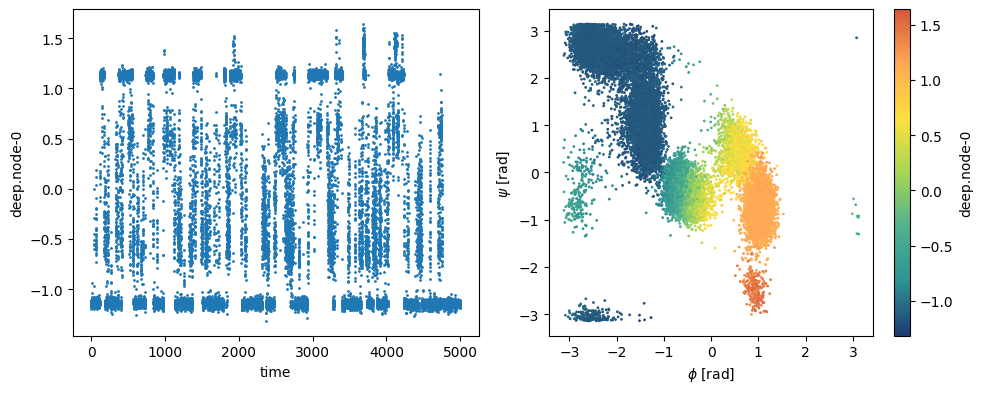

In [75]:
import mlcolvar.utils.plot
from mlcolvar.utils.io import load_dataframe
colvar = load_dataframe(f"{folder}/COLVAR")

fig,axs = plt.subplots(1,2,figsize=(10,4),dpi=100)
# Time evolution (DeepLDA)
colvar.plot.scatter('time','deep.node-0',s=1,ax=axs[0])
axs[1].set_xlabel('Time [ps]')
axs[1].set_xlabel('DeepLDA')
# 2D scatter plot colored with DeepLDA
colvar.plot.scatter('phi','psi',c='deep.node-0',s=1,cmap='fessa',ax=axs[1])
axs[1].set_xlabel(r'$\phi$ [rad]')
axs[1].set_ylabel(r'$\psi$ [rad]')
axs[1].set_aspect('equal')

plt.tight_layout()
plt.show()

In [25]:
colvar.head()

,time,phi,psi,theta,xi,ene,d_2_5,d_2_6,d_2_7,d_2_9,...,d_11_19,d_15_16,d_15_17,d_15_19,d_16_17,d_16_19,d_17_19,deep.node-0,metad.bias,walker
0,0.0,-2.36867,2.64432,-0.202258,0.048056,-41.45830,0.152064,0.233505,0.241173,0.379827,...,0.452694,0.126976,0.130073,0.244001,0.227324,0.281913,0.148169,-1.13657,0.0,0
1,0.2,-2.01898,2.09469,0.183210,-0.178198,-26.62960,0.155184,0.240710,0.248149,0.389691,...,0.475079,0.123270,0.131440,0.242846,0.224891,0.277797,0.147679,-1.11136,0.0,0
2,0.4,-1.13139,2.51985,-0.281659,0.294618,-2.19324,0.153063,0.234471,0.243033,0.374476,...,0.473166,0.118082,0.137847,0.252739,0.232262,0.299266,0.149680,-1.16755,0.0,0
3,0.6,-1.64721,2.11314,0.231530,-0.183816,-15.40100,0.159816,0.246010,0.253918,0.392053,...,0.482696,0.119017,0.136940,0.255319,0.226818,0.292098,0.151715,-1.17597,0.0,0
4,0.8,-1.69177,2.11845,-0.329666,0.034495,-10.47410,0.149143,0.235045,0.235169,0.376047,...,0.474980,0.125090,0.132779,0.237819,0.225958,0.269223,0.143853,-1.13440,0.0,0


(0.0, 50.0)

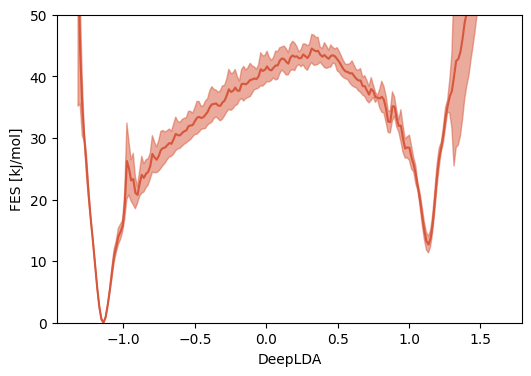

In [76]:
from mlcolvar.utils.fes import compute_fes

s = colvar['deep.node-0'].values

# compute weights
kbT = 2.5
w = np.exp(colvar['metad.bias'].values/kbT)

fig,ax = plt.subplots(figsize=(6,4),dpi=100)
fes,grid,bounds,error = compute_fes(s, weights=w, kbt=kbT, 
                                    blocks=5, bandwidth=0.01, 
                                    plot=True, ax = ax)
ax.set_xlabel('DeepLDA')
ax.set_ylabel('FES [kJ/mol]')
ax.set_ylim(0,50)

--> **Exercise**: calculate the FES as a function of other variables, such as the Ramachandran angles `phi` and `psi`.

Note: the function `compute_fes` uses the function `KernelDensity` from scikit-learn package to perform Kernel Density Estimation (KDE). While this allows us to easily perform KDE on many dimensions, we need to take into account the periodicity of the CV. One simple solution is to perform data augmentation

In [77]:
def augment_periodic(cv,weights=None,bandwidth=0.1):
    """Add points across the periodic boundaries (-np.pi and np.pi)

    Parameters
    ----------
    cv : np.array
    weigths : np.array, optional
    bandwidth : float, optional
    """
    mask = (cv < -np.pi + 3*bandwidth)
    index = np.argwhere(mask)[:,0]
    cv = np.insert( cv, index, cv[mask] + 2*np.pi )
    if weights is not None:
        weights = np.insert( weights, index, weights[mask] )

    mask = (cv > np.pi  - 5*bandwidth) & ( cv < np.pi )
    index = np.argwhere(mask)[:,0]
    cv = np.insert( cv, np.argwhere(mask)[:,0], cv[mask] - 2*np.pi )
    if weights is not None:
        weights = np.insert( weights, index, weights[mask] )

    return cv, weights

phi = colvar['phi'].values
psi = colvar['psi'].values
w = np.exp(colvar['metad.bias'].values/kbT)

bandwidth = 0.05

phi, w_phi = augment_periodic(phi,w,bandwidth)
psi, w_psi = augment_periodic(psi,w,bandwidth)

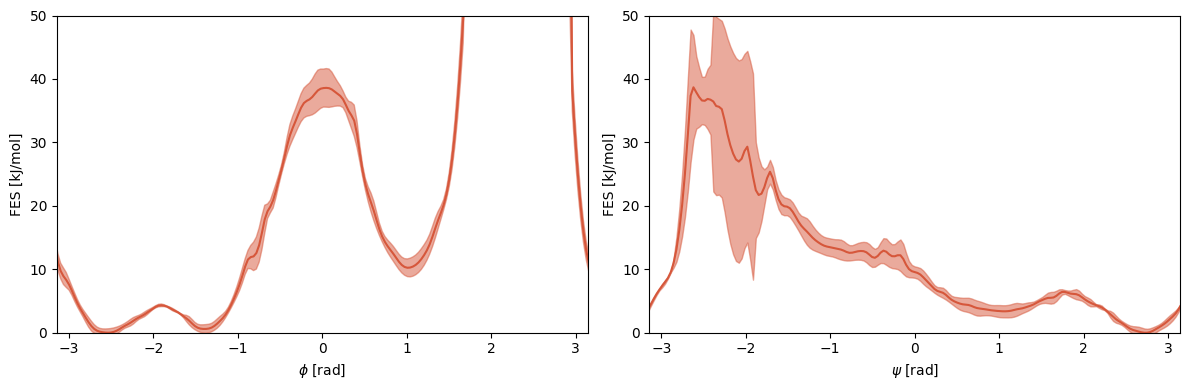

In [78]:
# compute weights
kbT = 2.5

#w = np.exp(colvar['metad.bias'].values/kbT)

#phi = colvar['phi'].values

fig,axs = plt.subplots(1,2,figsize=(12,4),dpi=100)
ax = axs[0]
fes,grid,bounds,error = compute_fes(phi, weights=w_phi, kbt=kbT, 
                                    blocks=5, bandwidth=bandwidth, 
                                    plot=True, ax = ax)
ax.set_xlabel(r'$\phi$ [rad]')
ax.set_ylabel('FES [kJ/mol]')
ax.set_xlim(-np.pi,np.pi)
ax.set_ylim(0,50)

ax = axs[1]
fes,grid,bounds,error = compute_fes(psi, weights=w_psi, kbt=kbT, 
                                    blocks=5, bandwidth=bandwidth, 
                                    plot=True, ax = ax)
ax.set_xlabel(r'$\psi$ [rad]')
ax.set_ylabel('FES [kJ/mol]')
ax.set_xlim(-np.pi,np.pi)
ax.set_ylim(0,50)

plt.tight_layout()

Once we have obtained a reasonable sampling, we can try to understand what the NN has learnt. A naive guess would be to compute the correlation between the DeepLDA CV and all the input distances. 

--> **Question**: Can we identify some features that are more correlated than others? You can also try to use `method='spearman'` in the correlation function, which rather than looking for a linear correlation only assesses how well the relationship between two variables can be described using a monotonic function.

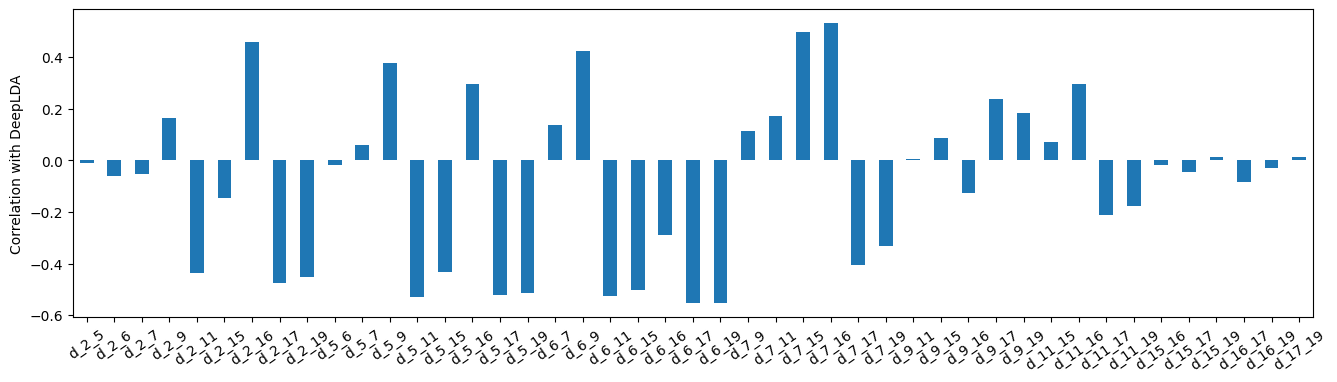

In [79]:
cols = ['deep.node-0']
cols.extend(colvar.filter(regex='d_').columns)
corr = colvar[cols].corr(method='pearson') 

fig,ax = plt.subplots(figsize=(16,4),dpi=100)

corr['deep.node-0'].drop('deep.node-0').plot(kind='bar', ax=ax, rot=35)
ax.set_ylabel('Correlation with DeepLDA')
plt.show()

Since the relationship between the input distances and the DeepLDA CV is not linear, understanding what the NN has learnt might not be an easy job. Hovewer, we could try to see whether we detect any correlation with respect to other physical descriptors which might play a role in the transition between the two states. 

--> **Exercise**: compute the correlation between the DeepLDA CV and the torsion angles computed in the PLUMED input file.

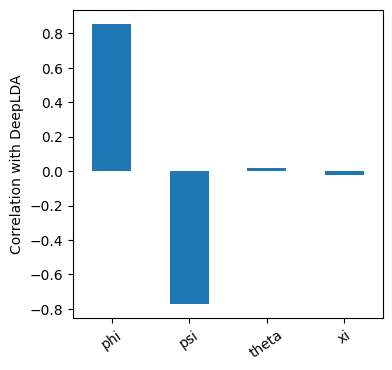

In [80]:
# select deelda and input distances, as well as dihedral angles
#cols = ['deep.node-0', ______FILL______ ]
cols = ['deep.node-0', 'phi', 'psi', 'theta', 'xi']

# compute correlation
corr = colvar[cols].corr(method='spearman')

# plot
fig,ax = plt.subplots(figsize=(4,4),dpi=100)
corr['deep.node-0'].drop('deep.node-0').plot(kind='bar', ax=ax, rot=35)
ax.set_ylabel('Correlation with DeepLDA')
plt.show()

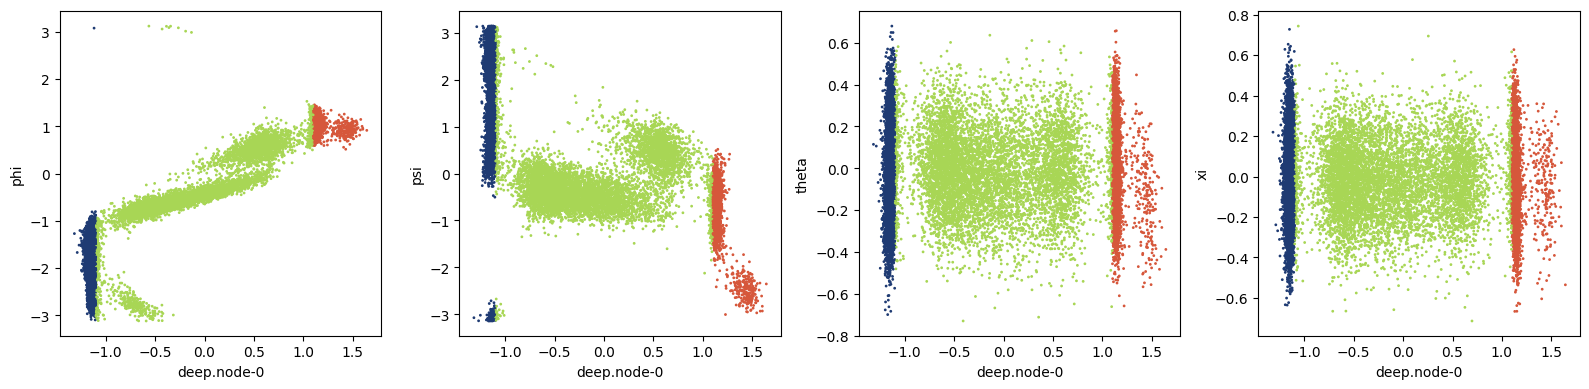

In [81]:
fig,axs = plt.subplots(1,len(cols)-1,figsize=(16,4),dpi=100)

state = np.zeros(len(colvar))

state[colvar['deep.node-0']<-1.1] = -1
state[colvar['deep.node-0']>1.1] = 1

colvar['state'] = state

for i,desc in enumerate(cols[1:]):
    colvar.plot.scatter('deep.node-0',desc,c='state',s=1,ax=axs[i],cmap='fessa',colorbar=False)

plt.tight_layout()

### Bonus exercise: stretching the CV

As you might have noticed, the DeepLDA CV acts as a powerful classifier, which maps the equilibrium fluctuations into very narrow distributions. Although we were using OPES with adaptive bandwitdh estimation, this might still lead to artifacts in the enhanced sampling dynamics. To address this behaviour we can work on the regularization of the NN (e.g. penalty functions to the loss function) or, in this case, we can more simply stretch it. Since the states are mapped (due to the lorentzian regularization) on a sphere of radius ~ 1.1, if we use a function of the kind `s' = s + s^N` we obtain a transformation of the CV which is approximately linear around zero and amplifies the fluctuations around 1. In the picture below you can see the case for N=3. 

You can try to repeat the enhanced sampling simulation biasing a function of the CV, using the `CUSTOM` PLUMED keyword, e.g.:

`deep_mod: CUSTOM ARG=deep.node-0 FUNC=x+x^3 PERIODIC=NO`

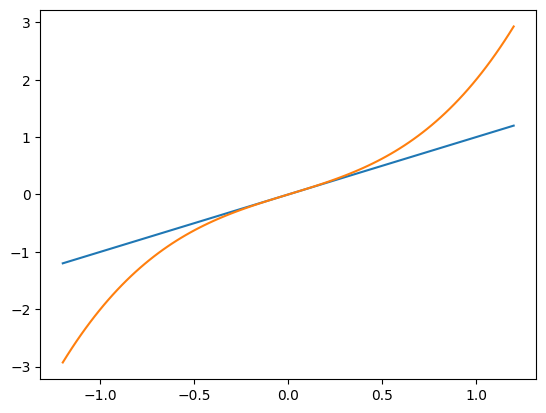

In [37]:
x = np.linspace(-1.2,1.2,100)
plt.plot(x,x)
plt.plot(x,x+x**3)
plt.show()

In [43]:
folderS = DATA_DIR / "1_meta-deeplda-stretch/"
Path(folderS).mkdir(parents=True, exist_ok=True)
execute(f"cp {MD_IN_DIR}/input.ala2.pdb .", folderS)
execute(f"cp {MD_IN_DIR}/input.tpr .", folderS)

# export model
execute(f"cp {folder}/model.ptc .", folder=folderS)

Completed: cp /home/dani/wslcoding/MCFM/ML-CV/input/md_inputs/input.ala2.pdb .
Completed: cp /home/dani/wslcoding/MCFM/ML-CV/input/md_inputs/input.tpr .
Completed: cp /home/dani/wslcoding/MCFM/ML-CV/data/1_meta-deeplda/model.ptc .


In [54]:
# WRITE PLUMED INPUT FILE
with open(folderS / "plumed.dat", "w") as f:
    f.write(f"""\
# vim:ft=plumed

# Compute torsion angles, as well as energy
MOLINFO STRUCTURE=input.ala2.pdb
phi: TORSION ATOMS=@phi-2
psi: TORSION ATOMS=@psi-2
theta: TORSION ATOMS=6,5,7,9
xi: TORSION ATOMS=16,15,17,19
ene: ENERGY

# Compute descriptors
INCLUDE FILE={INPUT_DIR}/plumed-distances.dat

# Compute DeepLDA CV
deep: PYTORCH_MODEL FILE=model.ptc    ARG=d_2_5,d_2_6,d_2_7,d_2_9,d_2_11,d_2_15,d_2_16,d_2_17,d_2_19,d_5_6,d_5_7,d_5_9,d_5_11,d_5_15,d_5_16,d_5_17,d_5_19,d_6_7,d_6_9,d_6_11,d_6_15,d_6_16,d_6_17,d_6_19,d_7_9,d_7_11,d_7_15,d_7_16,d_7_17,d_7_19,d_9_11,d_9_15,d_9_16,d_9_17,d_9_19,d_11_15,d_11_16,d_11_17,d_11_19,d_15_16,d_15_17,d_15_19,d_16_17,d_16_19,d_17_19

# Stretch the CV
deep_mod: CUSTOM ARG=deep.node-0 FUNC=x+x^3 PERIODIC=NO

metad: METAD ARG=deep_mod ...
   # Deposit a Gaussian every 500 time steps, with initial height 
   # equal to 1.2 kJ/mol and bias factor equal to 8 
   PACE=500 HEIGHT=1.2 BIASFACTOR=8 
   # Gaussian width (sigma) should be chosen based on the CV fluctuations in unbiased run 
   SIGMA=0.3 
   # Gaussians will be written to file and also stored on grid 
   FILE=HILLS GRID_MIN=-50 GRID_MAX=50 
...

# Print 
PRINT FMT=%g STRIDE={STRIDE} FILE=COLVAR ARG=*
ENDPLUMED
""")

In [ ]:
#clean(folderS) # note: this deletes all previous results in folder!

In [55]:
# RUN GROMACS

execute(f"{GMX_CMD} mdrun -s input.tpr -deffnm alanine -plumed plumed.dat -ntomp 1 -nsteps {test_num_steps} > alanine.out", folder=folderS)

Completed: gmx_mpi mdrun -s input.tpr -deffnm alanine -plumed plumed.dat -ntomp 1 -nsteps 10000 > alanine.out


In [57]:
# print command to run in terminal (for longer run)

print(f"cd {folderS}")
print(f"{GMX_CMD} mdrun -s input.tpr -deffnm alanine -plumed plumed.dat -ntomp 1 -nsteps {num_steps} -v")

cd /home/dani/wslcoding/MCFM/ML-CV/data/1_meta-deeplda-stretch
gmx_mpi mdrun -s input.tpr -deffnm alanine -plumed plumed.dat -ntomp 1 -nsteps 500000 -v


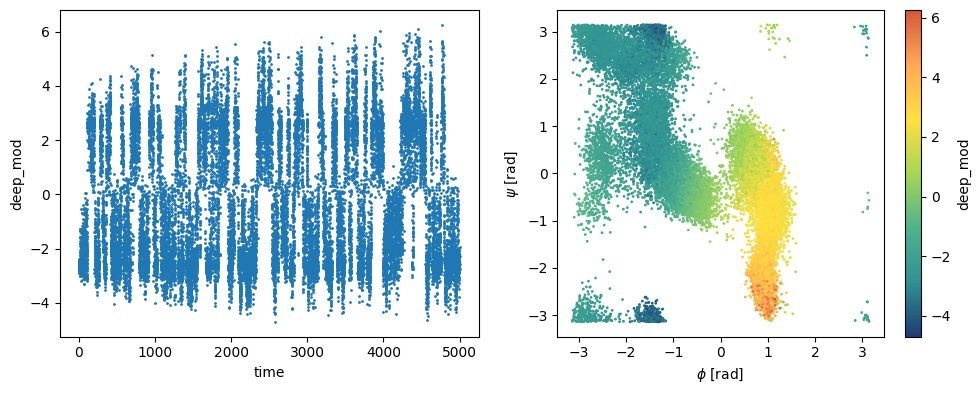

In [66]:
colvarS = load_dataframe(f"{folderS}/COLVAR")

fig,axs = plt.subplots(1,2,figsize=(10,4),dpi=100)
# Time evolution (DeepLDA)
colvarS.plot.scatter('time','deep_mod',s=1,ax=axs[0])
axs[1].set_xlabel('Time [ps]')
axs[1].set_xlabel('DeepLDA')
# 2D scatter plot colored with DeepLDA
colvarS.plot.scatter('phi','psi',c='deep_mod',s=1,cmap='fessa',ax=axs[1])
axs[1].set_xlabel(r'$\phi$ [rad]')
axs[1].set_ylabel(r'$\psi$ [rad]')
axs[1].set_aspect('equal')

plt.tight_layout()
plt.show()

In [69]:
colvarS.head()

,time,phi,psi,theta,xi,ene,d_2_5,d_2_6,d_2_7,d_2_9,...,d_15_16,d_15_17,d_15_19,d_16_17,d_16_19,d_17_19,deep.node-0,deep_mod,metad.bias,walker
0,0.0,-2.36867,2.64432,-0.202258,0.048056,-41.4583,0.152064,0.233505,0.241173,0.379827,...,0.126976,0.130073,0.244001,0.227324,0.281913,0.148169,-1.13657,-2.60479,0.0,0
1,0.2,-2.01898,2.09469,0.183210,-0.178198,-26.6296,0.155184,0.240710,0.248149,0.389691,...,0.123270,0.131440,0.242846,0.224891,0.277797,0.147679,-1.11136,-2.48401,0.0,0
2,0.4,-1.13139,2.51985,-0.281652,0.294623,-2.1900,0.153063,0.234471,0.243034,0.374476,...,0.118082,0.137848,0.252739,0.232262,0.299266,0.149679,-1.16755,-2.75911,0.0,0
3,0.6,-1.64719,2.11313,0.231522,-0.183849,-15.4026,0.159815,0.246008,0.253919,0.392052,...,0.119017,0.136940,0.255320,0.226817,0.292097,0.151716,-1.17598,-2.80230,0.0,0
4,0.8,-1.69173,2.11844,-0.329689,0.034487,-10.4736,0.149141,0.235044,0.235169,0.376046,...,0.125090,0.132779,0.237819,0.225958,0.269222,0.143853,-1.13441,-2.59425,0.0,0


(0.0, 50.0)

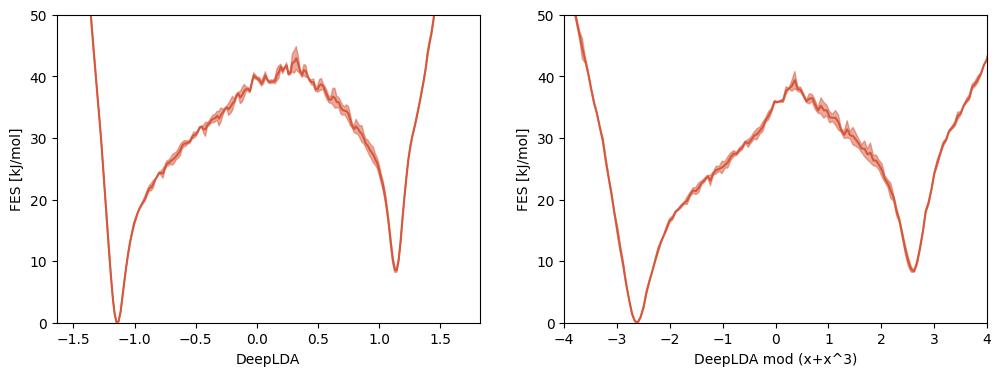

In [74]:
s = colvarS['deep.node-0'].values
s2 = colvarS['deep_mod'].values

# compute weights
kbT = 2.5
w = np.exp(colvarS['metad.bias'].values/kbT)

fig,axs = plt.subplots(1,2,figsize=(12,4),dpi=100)
ax = axs[0]
fes,grid,bounds,error = compute_fes(s, weights=w, kbt=kbT, 
                                    blocks=5, bandwidth=0.01, 
                                    plot=True, ax = ax)
ax.set_xlabel('DeepLDA')
ax.set_ylabel('FES [kJ/mol]')
ax.set_ylim(0,50)

ax = axs[1]
fes,grid,bounds,error = compute_fes(s2, weights=w, kbt=kbT, 
                                    blocks=5, bandwidth=0.02, 
                                    plot=True, ax = ax)
ax.set_xlabel('DeepLDA mod (x+x^3)')
ax.set_ylabel('FES [kJ/mol]')
ax.set_xlim(-4,4)
ax.set_ylim(0,50)